<a href="https://colab.research.google.com/github/suparuek2405/credit-default-dl/blob/main/notebooks/05_TabPFN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NB05 — TabPFN-3: Foundation Model Benchmark
# Project: Credit Card Default Prediction
# Dataset: UCI Credit Card Default (30,000 samples, 40 features)
# Goal: Benchmark TabPFN-3 against TabNet (AUC 0.7744)

In [3]:
!pip install -U tabpfn -q
print("TabPFN-3 installed.")
print("NOTE: First call to .fit() will open a browser tab for a one-time PriorLabs login (free account).")


TabPFN-3 installed.
NOTE: First call to .fit() will open a browser tab for a one-time PriorLabs login (free account).


In [4]:
# Load Data
# We reuse the same src/ pipeline as NB02–NB04 to guarantee identical splits.
# Same random_state=42, same stratification → no leakage, fair comparison.

import sys
sys.path.append('/content/credit-default-dl')

import pandas as pd
import numpy as np

from src.features import engineer_features
from src.dataset import load_and_split   # ← correct function name

# ── Load raw CSV ──────────────────────────────────────────────
# Try both common filenames for the UCI dataset
import os
for fname in ['UCI_Credit_Card.csv', 'credit_card_default.csv',
              'default of credit card clients.csv']:
    path = f'data/{fname}'
    if os.path.exists(path):
        raw = pd.read_csv(path, index_col=0)
        print(f"Loaded: {path}  {raw.shape}")
        break
else:
    raise FileNotFoundError("CSV not found in data/ — upload it via Colab Files panel")

# ── Rename target to 'target' (what src/dataset.py expects) ──
raw = raw.rename(columns={'default.payment.next.month': 'target'})

# ── Feature engineering (same 17 features as NB02–NB04) ──────
df = engineer_features(raw)
print(f"After engineering: {df.shape[1]} features")

# ── Split (identical to all previous notebooks) ───────────────
(X_train, X_val, X_test,
 y_train, y_val, y_test,
 scaler, feature_names) = load_and_split(df)

print(f"\nTrain : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"Val   : {X_val.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")
print(f"Default rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")


Loaded: data/UCI_Credit_Card.csv  (30000, 24)
After engineering: 41 features

Train : 21,012 rows | 40 features
Val   : 4,488 rows
Test  : 4,500 rows
Default rate — Train: 0.221 | Test: 0.221


In [5]:
import os
os.environ["TABPFN_TOKEN"] = "xxx"

from tabpfn import TabPFNClassifier
import time

clf = TabPFNClassifier()

print("Fitting TabPFN-3 ...")
start = time.time()
clf.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Fit complete in {elapsed:.1f}s")

Fitting TabPFN-3 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v3-classifier-v3_default.ckpt:   0%|          | 0.00/213M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/33.0 [00:00<?, ?B/s]

Fit complete in 7.2s


In [6]:
# Evaluate
from sklearn.metrics import roc_auc_score, classification_report

proba = clf.predict_proba(X_test)[:, 1]
auc   = roc_auc_score(y_test, proba)

print("=" * 45)
print(f"  TabPFN-3 Test AUC : {auc:.4f}")
print(f"  TabNet   Test AUC : 0.7744  (NB04 best)")
print(f"  Difference        : {auc - 0.7744:+.4f}")
print("=" * 45)

# Threshold at 0.5 for classification report
preds = (proba >= 0.5).astype(int)
print("\nClassification Report (threshold = 0.5):")
print(classification_report(y_test, preds, target_names=["No Default", "Default"]))

  TabPFN-3 Test AUC : 0.7889
  TabNet   Test AUC : 0.7744  (NB04 best)
  Difference        : +0.0145

Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      3505
     Default       0.68      0.35      0.46       995

    accuracy                           0.82      4500
   macro avg       0.76      0.65      0.68      4500
weighted avg       0.80      0.82      0.80      4500



In [7]:
# Optimal threshold by F1 on Default class
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_thresh = thresholds[f1_scores[:-1].argmax()]

preds_opt = (proba >= best_thresh).astype(int)
print(f"Optimal threshold: {best_thresh:.3f}")
print(classification_report(y_test, preds_opt, target_names=["No Default", "Default"]))

Optimal threshold: 0.269
              precision    recall  f1-score   support

  No Default       0.88      0.87      0.87      3505
     Default       0.55      0.57      0.56       995

    accuracy                           0.80      4500
   macro avg       0.71      0.72      0.72      4500
weighted avg       0.80      0.80      0.80      4500



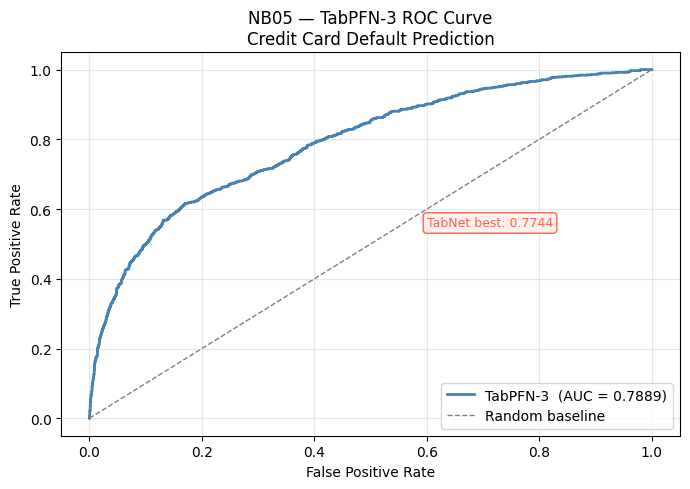

Saved: results/figures/19_tabpfn3_roc.png


In [12]:
# ROC Curve
# We overlay TabPFN-3 against the TabNet baseline to visualize the gap.

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import os

fpr, tpr, _ = roc_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'TabPFN-3  (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Random baseline')

ax.annotate(f'TabNet best: 0.7744', xy=(0.6, 0.55), fontsize=9, color='tomato',
            bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='tomato'))

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('NB05 — TabPFN-3 ROC Curve\nCredit Card Default Prediction')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()

os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/19_tabpfn3_roc.png', dpi=150)
plt.show()
print("Saved: results/figures/19_tabpfn3_roc.png")

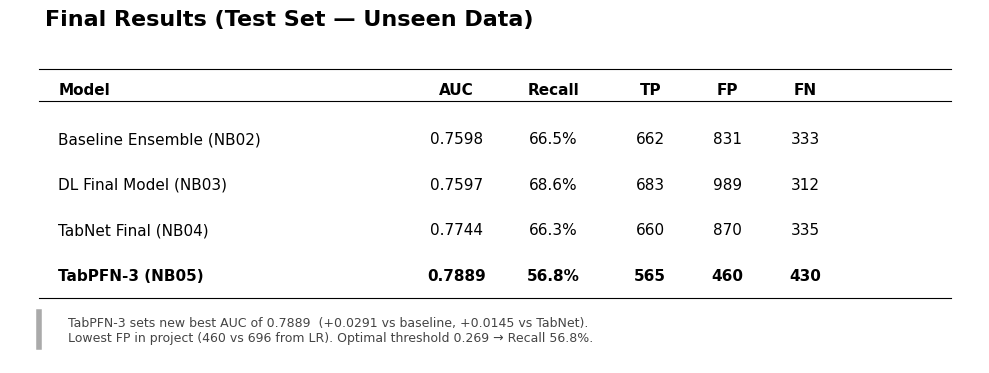

Saved: results/figures/20_results_table_nb05.png


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ── Compute TabPFN-3 values ────────────────────────────────────
thresh_opt = 0.269
preds_opt  = (proba >= thresh_opt).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, preds_opt).ravel()
recall_opt = tp / (tp + fn)

# ── Table data ─────────────────────────────────────────────────
rows = [
    ("Baseline Ensemble (NB02)", 0.7598, 0.665, 662,     831,  333,  False),
    ("DL Final Model (NB03)",    0.7597, 0.686, 683,     989,  312,  False),
    ("TabNet Final (NB04)",      0.7744, 0.663, 660,     870,  335,  False),
    ("TabPFN-3 (NB05)",          auc,  recall_opt, int(tp), int(fp), int(fn), True),
]

col_labels = ["Model", "AUC", "Recall", "TP", "FP", "FN"]
col_x      = [0.05, 0.46, 0.56, 0.66, 0.74, 0.82]
col_align  = ["left", "center", "center", "center", "center", "center"]
header_y   = 0.78
row_h      = 0.13

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.axis("off")
t = ax.transAxes

# Title
fig.text(0.05, 0.97, "Final Results (Test Set — Unseen Data)",
         fontsize=16, fontweight="bold", va="top", ha="left")

# Header
for i, label in enumerate(col_labels):
    ax.text(col_x[i], header_y, label, transform=t,
            fontsize=11, fontweight="bold", ha=col_align[i], va="center")

# Divider lines — use ax.plot with transform instead of axhline
for y_line in [header_y + 0.06, header_y - 0.03]:
    ax.plot([0.03, 0.97], [y_line, y_line], color="black",
            linewidth=0.8, transform=t, clip_on=False)

# Rows
for r_idx, (model, model_auc, recall, tp_val, fp_val, fn_val, is_best) in enumerate(rows):
    y      = header_y - 0.03 - row_h * (r_idx + 0.85)
    weight = "bold" if is_best else "normal"
    vals   = [model, f"{model_auc:.4f}", f"{recall*100:.1f}%",
              str(tp_val), str(fp_val), str(fn_val)]
    for i, val in enumerate(vals):
        ax.text(col_x[i], y, val, transform=t,
                fontsize=11, fontweight=weight, ha=col_align[i], va="center")

# Bottom divider
bot_y = header_y - 0.03 - row_h * (len(rows) + 0.35)
ax.plot([0.03, 0.97], [bot_y, bot_y], color="black",
        linewidth=0.8, transform=t, clip_on=False)

# Note with grey bar
note_y = bot_y - 0.09
ax.plot([0.03, 0.03], [note_y - 0.05, note_y + 0.05],
        color="#AAAAAA", linewidth=4, transform=t, clip_on=False)
ax.text(0.06, note_y,
        f"TabPFN-3 sets new best AUC of {auc:.4f}  "
        f"(+{auc-0.7598:.4f} vs baseline, +{auc-0.7744:.4f} vs TabNet).\n"
        f"Lowest FP in project ({int(fp)} vs 696 from LR). "
        f"Optimal threshold 0.269 → Recall {recall_opt*100:.1f}%.",
        transform=t, fontsize=9, color="#444444", va="center", ha="left")

plt.tight_layout()
plt.savefig("results/figures/20_results_table_nb05.png",
            dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: results/figures/20_results_table_nb05.png")

In [14]:
# Full comparison table

results = {
    'NB02 | Logistic Regression':   0.7451,
    'NB02 | XGBoost':               0.7387,
    'NB02 | LinearSVC':             0.7456,
    'NB02 | Ensemble (soft vote)':  0.7598,
    'NB03 | MLP + Attention':       0.7597,
    'NB04 | TabNet':                0.7744,
    'NB05 | TabPFN-3':              auc,
}

best = max(results.values())

print(f"\n{'Model':<40} {'AUC':>8}")
print("-" * 52)
for model, score in sorted(results.items(), key=lambda x: x[1]):
    marker = "  ← BEST" if score == best else ""
    print(f"{model:<40} {score:.4f}{marker}")

print(f"\nTabPFN-3 vs TabNet: {auc - 0.7744:+.4f}")
print(f"TabPFN-3 vs Ensemble baseline: {auc - 0.7598:+.4f}")


Model                                         AUC
----------------------------------------------------
NB02 | XGBoost                           0.7387
NB02 | Logistic Regression               0.7451
NB02 | LinearSVC                         0.7456
NB03 | MLP + Attention                   0.7597
NB02 | Ensemble (soft vote)              0.7598
NB04 | TabNet                            0.7744
NB05 | TabPFN-3                          0.7889  ← BEST

TabPFN-3 vs TabNet: +0.0145
TabPFN-3 vs Ensemble baseline: +0.0291
